In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.util import invert
from scipy.interpolate import splprep, splev
from shapely.geometry import LineString, Point
from scipy.ndimage import center_of_mass
from scipy.spatial.distance import cdist

# Import functions from the utils directory
from utils.snakeFunctions import findSnake, find_endpoints, trace_skeleton, smoothCenterline
from utils.snakeWidth import estimateWidths
from utils.snakeMOI import calculate_moment_of_inertia_voronoi, convert_inertia_pixels_to_meters, convert_geometric_to_physical_inertia

In [2]:
import h5py
import numpy as np

# Constants
dt = 0.071

data_path = '/path/to/the/file/kinematics_images.mat' # <---- CHANGE THIS FOR YOUR COMPUTER

snake_ids = [f'snake{i}' for i in range(1, 7)]
fwd_trials = [f'fwd{i}' for i in range(1, 7)]

def load_kinematics_data(path):
    """
    Load kinematics_images.mat and return:
      - images: dict mapping turn-trial name -> image stack [height x width x channels x frame]
      - snakes: dict mapping snake name -> dict of scalar/measurement fields
        (in this notebook we will use the snake mass, body length, and mass from this file)
    """
    images = {}
    snakes = {}

    with h5py.File(path, 'r') as f:
        for trial in fwd_trials:
            arr = np.array(f['data'][trial])
            images[trial] = np.transpose(arr, axes=range(arr.ndim - 1, -1, -1))

        fields = ['avgMOI', 'stdMOI', 'avgAng', 'stdAng', 'avgH2T', 'stdH2T',
                  'bodyLength', 'mass', 'px2cm_turn', 'px2cm_fwd']
        for snake_id in snake_ids:
            snakes[snake_id] = {field: f[snake_id][field][()] for field in fields}

    return images, snakes

images, snakes = load_kinematics_data(data_path)

snake_mass = [snakes[s]['mass'] for s in snake_ids]
pixels_in_cm = [snakes[s]['px2cm_fwd'] for s in snake_ids]
bodyLength = [snakes[s]['bodyLength'] for s in snake_ids]

In [3]:
allCOM = []
allMOI = []
allSnakes = []

def prep_frame(img):
    """Convert an RGB frame from the h5py stack into what findSnake expects (BGR, uint8)."""
    if img.dtype != np.uint8:
        img = img.astype(np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

for snake_id, fwd_trial in zip(snake_ids, fwd_trials):
    img_stack = images[fwd_trial]        # [height, width, channels, frame]
    n_frames = img_stack.shape[-1]
    px2cm = snakes[snake_id]['px2cm_fwd']
    mass = snakes[snake_id]['mass']

    comList = []
    moiList = []
    snakeList = []

    for frame_idx in range(n_frames):
        img = prep_frame(img_stack[:, :, :, frame_idx])
        # Use image to find the binary image, contour and centerline
        snakeBW, snakeOutline, snakeSkel = findSnake(img)
        # Find endpoints of the centerline
        endpoints = find_endpoints(snakeSkel)
        if len(endpoints) >= 1:
            start_point = endpoints[0]
        else:
            raise ValueError("No endpoints found in the skeleton")
        # Trace the centerline path from start
        ordered_skeleton = trace_skeleton(snakeSkel, start_point)
        # Smooth the centerline and find evenly spaced points
        smoothLine = smoothCenterline(ordered_skeleton)
        # Calculate the center of mass and moment of inertia for the snake
        MOI_pixels, COM = calculate_moment_of_inertia_voronoi(snakeBW, smoothLine)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # img is BGR now, convert back for display
        plt.plot(COM[0], COM[1], 'o', color='#F59300')
        plt.axis('off')
        plt.clf()
        # Convert the moment of inertia from pixels^4 to m^4
        MOI_m = convert_inertia_pixels_to_meters(MOI_pixels, px2cm)
        MOI_kgm = convert_geometric_to_physical_inertia(MOI_m, snakeBW, px2cm, mass)
        comList.append(COM)
        moiList.append(MOI_kgm)
        snakeList.append(smoothLine)

    allCOM.append(comList)
    allMOI.append(moiList)
    allSnakes.append(snakeList)

<Figure size 640x480 with 0 Axes>

In [4]:
def hex_to_RGB(hex_str):
    """ #FFFFFF -> [255,255,255]"""
    #Pass 16 to the integer function for change of base
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):
    """
    Given two hex colors, returns a color gradient
    with n colors.
    """
    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


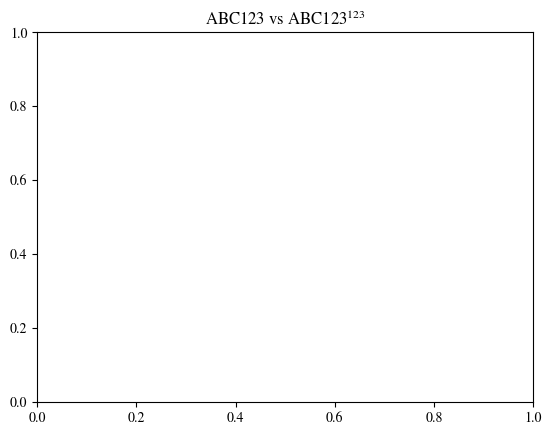

In [5]:
import numpy as np
import scipy.io as sio
import os
from scipy import ndimage
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.pyplot.title(r'ABC123 vs $\mathrm{ABC123}^{123}$')
matplotlib.rcParams.update({'font.size': 14})

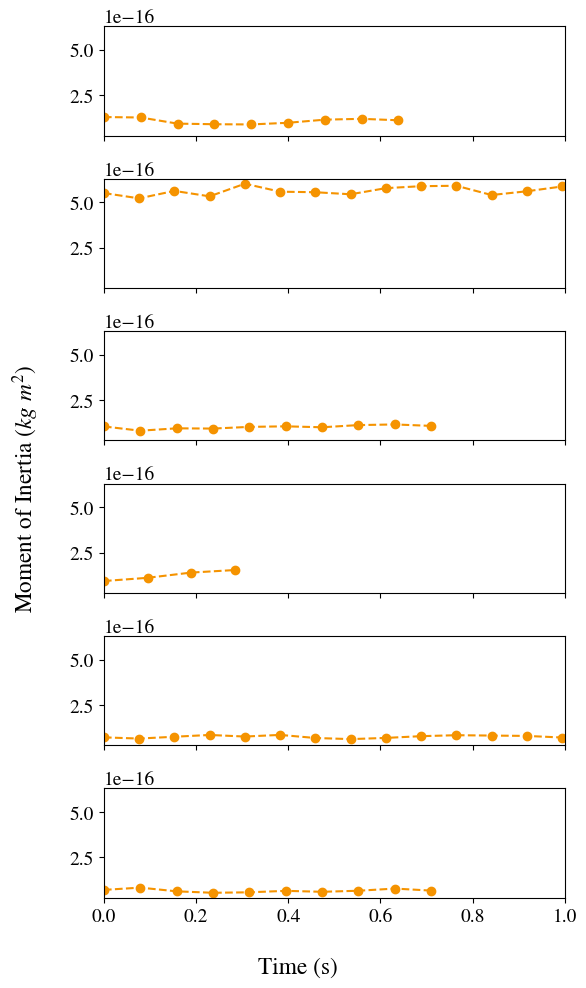

In [6]:
color1 = '#F59300'
fig_size = [6, 10]

fig, axs = plt.subplots(6, sharex=True, sharey=True, figsize=fig_size, tight_layout=True)

for i, snake_id in enumerate(snake_ids):
    moi = np.squeeze(np.array(allMOI[i]))
    time = np.linspace(0, dt * len(moi), len(moi))
    axs[i].plot(time, moi, 'o--', color=color1)

fig.supxlabel('Time (s)')
fig.supylabel('Moment of Inertia ($kg~m^2$)')
plt.xlim(0, 1)
plt.show()
# plt.ylim(0, 8e-16)
#plt.savefig(savePath + '/straight_moi.png', dpi=300)

In [7]:
allfirst_x = []
allfirst_y = []
alllast_x = []
alllast_y = []

for i in range(0,len(snakes)):
    first_x = []
    first_y = []
    last_x = []
    last_y = []
    
    for j in range(0,len(allSnakes[i])):
        first_x.append(allSnakes[i][j][0,0])
        first_y.append(allSnakes[i][j][0,1])
        last_x.append(allSnakes[i][j][-1,0])
        last_y.append(allSnakes[i][j][-1,1])

    allfirst_x.append(first_x)
    allfirst_y.append(first_y)
    alllast_x.append(last_x)
    alllast_y.append(last_y)

In [8]:
allHead = []
allTail = []

def whichPoint(start_here, point1, point2):
    distance1 = np.sqrt( (start_here[0] - point1[0])**2 + (start_here[1] - point1[1])**2 )
    distance2 = np.sqrt( (start_here[0] - point2[0])**2 + (start_here[1] - point2[1])**2 )

    next_point = point1 if distance1 < distance2 else point2
    
    return next_point

for i in range(0,len(snakes)):
    orderedHead = []
    orderedTail = []

    first_coord = (allfirst_x[i][0],allfirst_y[i][0])        
    last_coord  = ( alllast_x[i][0], alllast_y[i][0])

    orderedHead.append(first_coord)
    orderedTail.append(last_coord)
    
    for j in range(1,len(allfirst_x[i])):
        next1 = (allfirst_x[i][j],allfirst_y[i][j])
        next2 = ( alllast_x[i][j], alllast_y[i][j])
        
        nextHead = whichPoint(orderedHead[j-1],next1,next2)
        nextTail = whichPoint(orderedTail[j-1],next1,next2)

        if nextHead == nextTail:
            print('Error: head and tail are the same, snake = ',i,' picture = ',images[i][j])
        orderedHead.append(nextHead)
        orderedTail.append(nextTail)

    allHead.append(orderedHead)
    allTail.append(orderedTail)

In [9]:
# To create images of snake with COM, Head or Tail marked
heads = []; tails = []; coms = []
for i in range(0, len(snake_ids)):
    heads_tmp = np.array(allHead[i])
    tails_tmp = np.array(allTail[i])
    com_tmp   = np.array(allCOM[i])   # fixed: was allCOM[0]
    heads.append(heads_tmp)
    tails.append(tails_tmp)
    coms.append(com_tmp)

# Choose which snakes to visualize, e.g. [1, 3] for snake1 and snake3, or None for all
# snakes_to_plot = None  # e.g. [1, 3]
snakes_to_plot = [6]  # e.g. [1, 3]

selected_indices = range(len(fwd_trials)) if snakes_to_plot is None else [n - 1 for n in snakes_to_plot]

for i in selected_indices:
    fwd_trial = fwd_trials[i]
    img_stack = images[fwd_trial]
    n_frames = img_stack.shape[-1]
    for j in range(n_frames):
        img = img_stack[:, :, :, j]
        plt.imshow(img)
        plt.plot(coms[i][j,0], coms[i][j,1], 'o', color='darkgray',label='COM')
        plt.plot(heads[i][j,0], heads[i][j,1], 'o', color='deeppink',label='Head')
        plt.plot(tails[i][j,0], tails[i][j,1], 'o', color='orange',label='Tail')
        plt.legend()
        #plt.show()
        plt.clf()

<Figure size 640x480 with 0 Axes>

In [10]:
# Import math Library
import math

distanceCOM = []
velocityCOM = []
accelerationCOM = []

distanceHead = []
velocityHead = []
accelerationHead = []

distanceTail = []
velocityTail = []
accelerationTail = []


for i in range(0,len(snakes)):

    arrayCOM = np.array(allCOM[i])
    arrayHead = np.array(allHead[i])
    arrayTail = np.array(allTail[i])

    x_COM = arrayCOM[:,0]
    y_COM = arrayCOM[:,1]

    distance_COM = np.sqrt( ( x_COM[:-1] - x_COM[1:] )**2 + ( y_COM[:-1] - y_COM[1:] )**2 )
    distance_COM = distance_COM / ( pixels_in_cm[i][0, 0] * 100 )
    velocity_COM = distance_COM / dt
    acceleration_COM = velocity_COM / dt

    distanceCOM.append(distance_COM)
    velocityCOM.append(velocity_COM)
    accelerationCOM.append(acceleration_COM)

    x_Head = arrayHead[:,0]
    y_Head = arrayHead[:,1]

    distance_Head = np.sqrt( ( x_Head[:-1] - x_Head[1:] )**2 + ( y_Head[:-1] - y_Head[1:] )**2 )
    distance_Head = distance_Head / ( pixels_in_cm[i][0, 0] * 100 )
    velocity_Head = distance_Head / dt
    acceleration_Head = velocity_Head / dt

    distanceHead.append(distance_Head)
    velocityHead.append(velocity_Head)
    accelerationHead.append(acceleration_Head)
    
    x_Tail = arrayTail[:,0]
    y_Tail = arrayTail[:,1]

    distance_Tail = np.sqrt( ( x_Tail[:-1] - x_Tail[1:] )**2 + ( y_Tail[:-1] - y_Tail[1:] )**2 )
    distance_Tail = distance_Tail / ( pixels_in_cm[i][0, 0] * 100 )
    velocity_Tail = distance_Tail / dt
    acceleration_Tail = velocity_Tail / dt

    distanceTail.append(distance_Tail)
    velocityTail.append(velocity_Tail)
    accelerationTail.append(acceleration_Tail)

(0.0, 1.0)

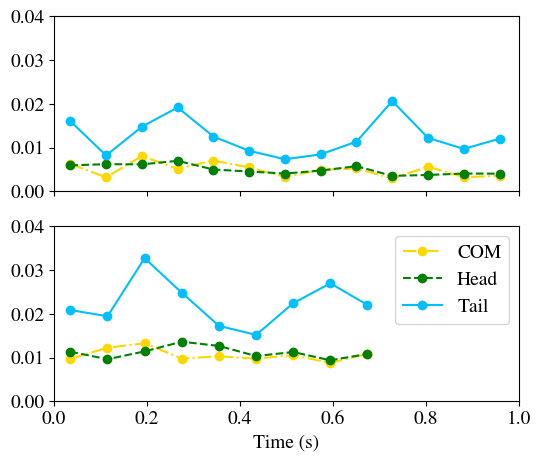

In [11]:
time_snake2 = np.linspace(0,dt*len(distanceCOM[1]),len(distanceCOM[1]))
time_snake6 = np.linspace(0,dt*len(distanceCOM[5]),len(distanceCOM[5]))

time_snake2 = time_snake2 + 0.0355
time_snake6 = time_snake6 + 0.0355

color2 = 'deepskyblue'
color1 = 'gold'
color3 = 'green'

fig_size = [6,5]
fig, axs = plt.subplots(2, sharex=True, sharey=True, figsize=fig_size)
#fig.suptitle('Center of Mass Movement')
#axs[0].settitle('Individual 3')
axs[0].plot(time_snake2, distanceCOM[1],'o-.',color=color1)
axs[1].plot(time_snake6, distanceCOM[5],'o-.',color=color1,label='COM')
axs[0].plot(time_snake2, distanceHead[1],'o--',color=color3)
axs[1].plot(time_snake6, distanceHead[5],'o--',color=color3,label='Head')
axs[0].plot(time_snake2, distanceTail[1],'o-',color=color2)
axs[1].plot(time_snake6, distanceTail[5],'o-',color=color2, label='Tail')
axs[1].legend()
plt.xlabel('Time (s)')
plt.ylim(0,0.04)
plt.xlim(0,1)
#plt.ylim(0,8e-16)
#plt.savefig(savePath + '/straight_com.png',dpi=300)

In [12]:
all_H2T = []
all_ang = []

moiSnakes = [allMOI[0], allMOI[1], allMOI[2], allMOI[3], allMOI[4], allMOI[5]]

for i in range(0,len(snakes)):
    arrayHead = np.array(allHead[i])
    arrayTail = np.array(allTail[i])

    H2T = np.sqrt( ( arrayHead[:,0] - arrayTail[:,0] )**2 + ( arrayHead[:,1] - arrayTail[:,1] )**2 )
    H2T = H2T / ( pixels_in_cm[i] * 100 )
    H2T = H2T / bodyLength[i]

    moiSnakes[i] = ( np.array(moiSnakes[i]) / bodyLength[i]**2 ) * 1000

    all_H2T.append(H2T)

    if i == 0 or i ==4 or i == 5: 
        # Hard code swap for the snakes that swam right to left
        dy = arrayHead[:,1] - arrayTail[:,1]
        dx = arrayHead[:,0] - arrayTail[:,0]
    else:
        dy = arrayTail[:,1] - arrayHead[:,1]
        dx = arrayTail[:,0] - arrayHead[:,0]

    rad = np.arctan2(dy, dx)
    ang = np.degrees(rad)

    all_ang.append(ang)
    

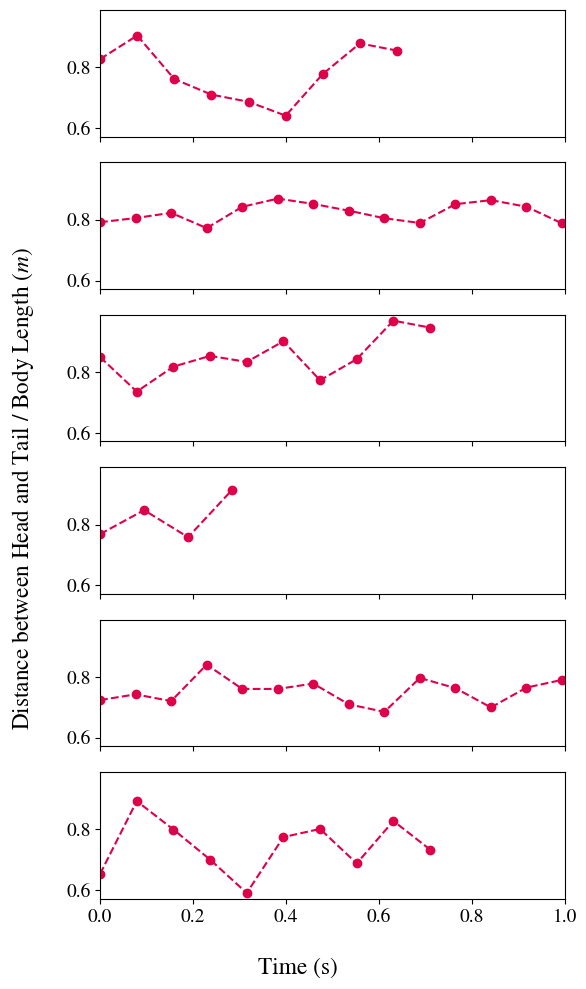

In [13]:
color1 = '#DE0049'
fig_size = [6, 10]

fig, axs = plt.subplots(6, sharex=True, sharey=True, figsize=fig_size, tight_layout=True)

for i, snake_id in enumerate(snake_ids):
    h2t = np.squeeze(np.array(all_H2T[i]))
    time = np.linspace(0, dt * len(h2t), len(h2t))
    axs[i].plot(time, h2t, 'o--', color=color1)

fig.supxlabel('Time (s)')
fig.supylabel('Distance between Head and Tail / Body Length ($m$)')
plt.xlim(0, 1)
plt.show()
# plt.ylim(0, 8e-16)
#plt.savefig(savePath + '/straight_moi.png', dpi=300)

(0.0, 1.0)

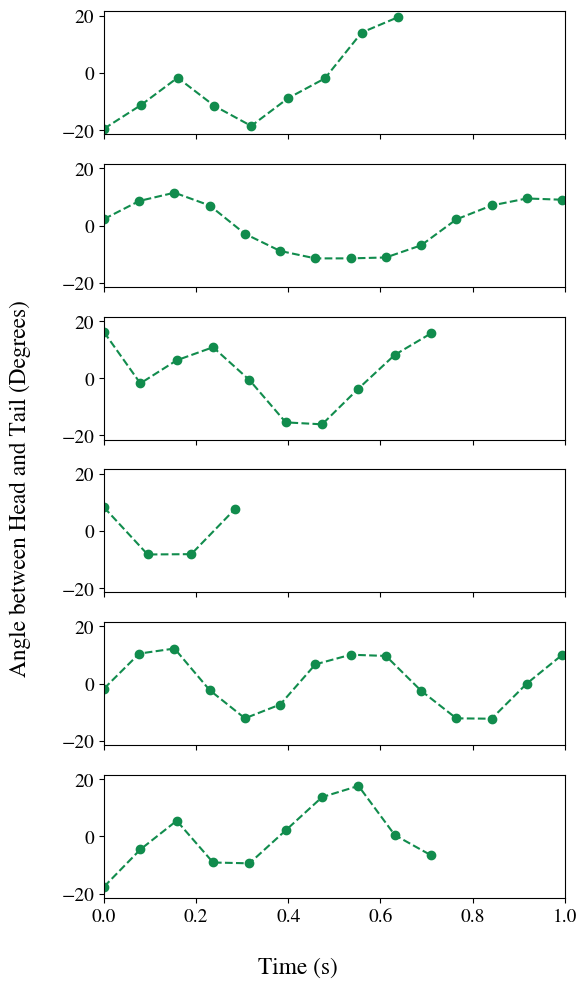

In [14]:
color2 = '#F59300'
color1 = '#DE0049'
color3 = '#118C4D'
color4 = '#0098B3'
fig_size = [6, 10]


fig, axs = plt.subplots(6, sharex=True, sharey=True, figsize=fig_size, tight_layout=True)

for i, snake_id in enumerate(snake_ids):
    ang = np.array(all_ang[i])
    shift = (ang.max() + ang.min()) / 2
    time = np.linspace(0, dt * len(all_ang[i]), len(all_ang[i]))
    axs[i].plot(time, ang - shift, 'o--', color=color3)

#axs[4].legend()
fig.supxlabel('Time (s)')
fig.supylabel('Angle between Head and Tail (Degrees)')
#plt.ylim(0,30)
plt.xlim(0, 1)
#plt.savefig(savePath + '/straight_ang.png', dpi=300)

In [15]:
import csv

avgMOI, stdMOI = [], []
avgH2T, stdH2T = [], []
avgHaus, stdHaus = [], []

for i in range(6):
    moi = np.array(allMOI[i])
    avgMOI.append(np.mean(moi))
    stdMOI.append(np.std(moi))

    h2t = np.array(all_H2T[i])
    avgH2T.append(np.mean(h2t))
    stdH2T.append(np.std(h2t))

    ang = np.array(all_ang[i])
    shift = (ang.max() + ang.min()) / 2
    avgHaus.append(np.mean(ang) - shift)
    stdHaus.append(np.std(ang))

save_array = zip(avgMOI, stdMOI, avgHaus, stdHaus, avgH2T, stdH2T)

save_file = '/path/to/save/the/file/straight_swimming.txt'
with open(save_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(save_array)